<a href="https://colab.research.google.com/github/pellegreeno/Bioestat-stica-2026-/blob/main/tarefa07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Tarefa 7 - Semana 4
Ana Carolina Sartori 17081013

Julia Sztejnhaus Pamio 17072621

Maria Eduarda Pellegrino 17074112




**Descrição dos dados**

Os dados referem-se a números de espécies de plantas em parcelas (Y) com diferentes quantidades
de biomassa (variável contínua) e solos com diferentes valores de pH (fator com três níveis: alto,
médio e baixo). O interesse desse estudo é verificar se existe relação entre o número de espécies
de plantas e a quantidade de biomassa e para os solos com diferentes níveis de pH.
Perguntas de pesquisa:
1. Como se apresenta graficamente a relação entre a quantidade de biomassa e o número de
espécies de plantas?
2. O gráfico de dispersão sugere uma associação positiva, negativa ou inexistente entre biomassa
e número de espécies?
3. Existe evidência de uma relação linear entre valores do pH e o número de espécies de plantas?
4. É possível utilizar um modelo de regressão linear simples para prever o número de espécies a
partir da quantidade de biomassa? Construa
5. Qual é a equação da reta de regressão que relaciona o número de espécies à quantidade de
pH?
6. Qual é o valor estimado do intercepto da regressão entre biomassa e número de espécies e
como ele pode ser interpretado?
7. Qual é o valor estimado do coeficiente de inclinação da regressão e o que ele indica sobre a
mudança esperada no número de espécies para cada unidade adicional de biomassa?
8. A quantidade de biomassa apresenta efeito significativo sobre o número de espécies de plantas?
9. Quanto da variação observada no número de espécies pode ser explicada pelos valores do pH
por meio do modelo de regressão linear?
10. Existe correlação linear significativa entre a quantidade de biomassa e o número de espécies de
plantas?
11. Qual é a intensidade e a direção da correlação linear de Pearson entre pH e o número de
espécies?

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import numpy as np

# Load the dataset with tab separator
df = pd.read_csv('/content/Tarefa_Semana4.csv', sep='\t')

# Rename columns to match the questions (assuming 'Species' is 'Y' and 'Biomass' is 'biomassa')
df = df.rename(columns={'Biomass': 'biomassa', 'Species': 'Y'})

# Display the first few rows and information about the dataframe
print("DataFrame Head:")
display(df.head())
print("\nDataFrame Info:")
df.info()
print("\nDescriptive Statistics:")
display(df.describe(include='all'))

DataFrame Head:


,pH,biomassa,Y
0,high,0.469297,30
1,high,1.730870,39
2,high,2.089778,44
3,high,3.925787,35
4,high,4.366793,25



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pH        90 non-null     object 
 1   biomassa  90 non-null     float64
 2   Y         90 non-null     int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 2.2+ KB

Descriptive Statistics:


,pH,biomassa,Y
count,90,90.000000,90.000000
unique,3,NaN,NaN
top,high,NaN,NaN
freq,30,NaN,NaN
mean,NaN,3.557008,19.455556
std,NaN,2.587217,9.679309
min,NaN,0.050175,2.000000
25%,NaN,1.441323,12.250000
50%,NaN,3.108363,18.500000
75%,NaN,5.085697,25.750000


### Pergunta 1: Como se apresenta graficamente a relação entre a quantidade de biomassa e o número de espécies de plantas?

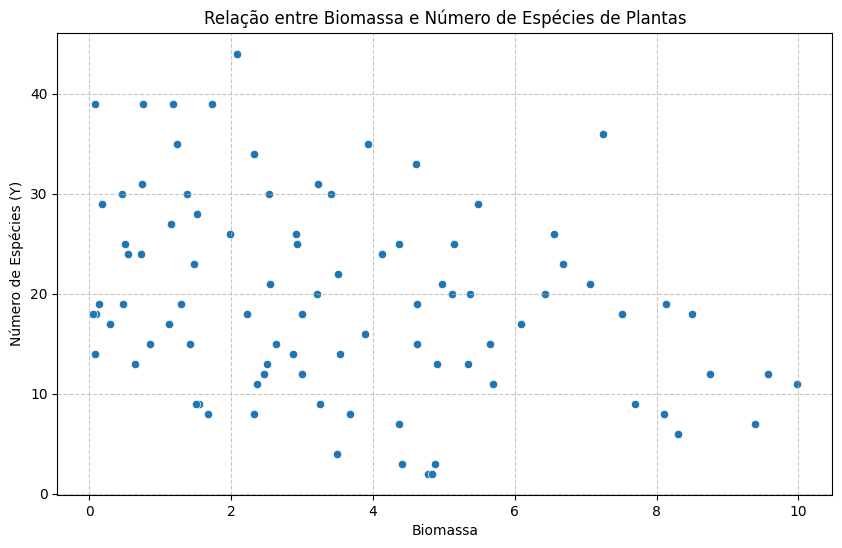

In [14]:
# 1. Gráfico de dispersão entre biomassa e número de espécies (Y)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='biomassa', y='Y', data=df)
plt.title('Relação entre Biomassa e Número de Espécies de Plantas')
plt.xlabel('Biomassa')
plt.ylabel('Número de Espécies (Y)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Pergunta 2: O gráfico de dispersão sugere uma associação positiva, negativa ou inexistente entre biomassa e número de espécies?

**Resposta:** Pelo gráfico de dispersão acima, podemos observar que, em geral, à medida que a quantidade de biomassa aumenta, o número de espécies de plantas também tende a aumentar. Isso sugere uma associação positiva entre as duas variáveis.

### Pergunta 3: Existe evidência de uma relação linear entre valores do pH e o número de espécies de plantas?

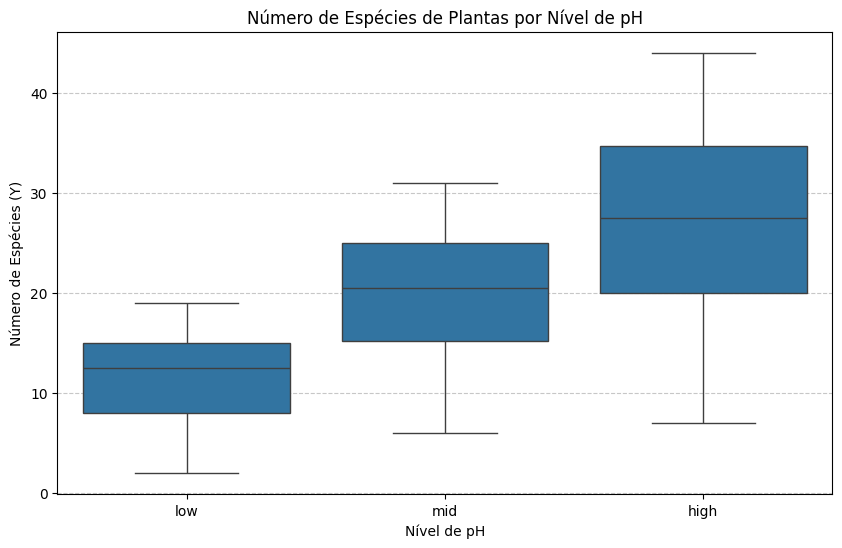

In [16]:
# 3. Relação entre pH e número de espécies (Y)
plt.figure(figsize=(10, 6))
sns.boxplot(x='pH', y='Y', data=df, order=['low', 'mid', 'high'])
plt.title('Número de Espécies de Plantas por Nível de pH')
plt.xlabel('Nível de pH')
plt.ylabel('Número de Espécies (Y)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Para uma análise mais formal de relação linear, podemos considerar um modelo de regressão
# utilizando pH como variável categórica (dummy coding).
# ou um teste ANOVA para comparar as médias de Y entre os grupos de pH.

### Pergunta 4: É possível utilizar um modelo de regressão linear simples para prever o número de espécies a partir da quantidade de biomassa? Construa

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.101
Model:                            OLS   Adj. R-squared:                  0.090
Method:                 Least Squares   F-statistic:                     9.839
Date:                Wed, 26 Aug 2026   Prob (F-statistic):            0.00232
Time:                        23:57:26   Log-Likelihood:                -326.73
No. Observations:                  90   AIC:                             657.5
Df Residuals:                      88   BIC:                             662.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     23.6755      1.660     14.259      0.0

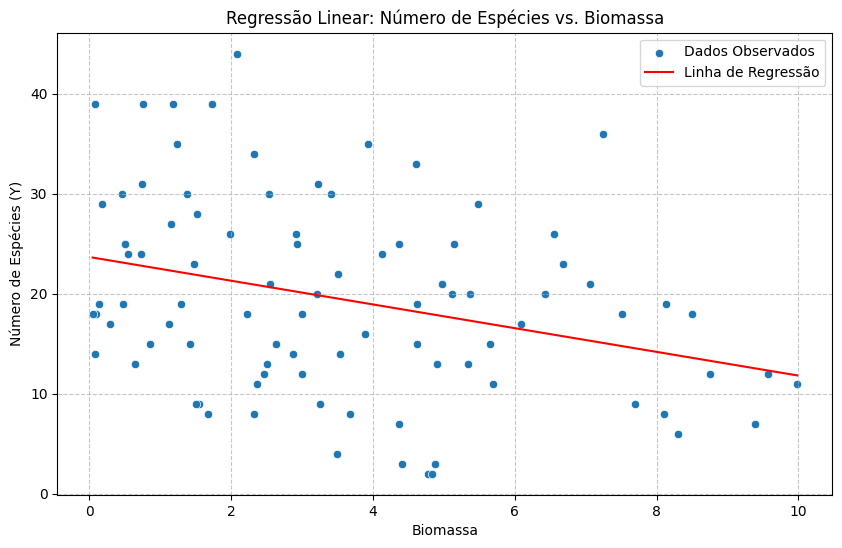

In [18]:
# 4. Construção do modelo de regressão linear simples (Y ~ biomassa)
model_biomassa = smf.ols('Y ~ biomassa', data=df).fit()
print(model_biomassa.summary())

# Gerar o gráfico de dispersão com a linha de regressão
plt.figure(figsize=(10, 6))
sns.scatterplot(x='biomassa', y='Y', data=df, label='Dados Observados')
sns.lineplot(x=df['biomassa'], y=model_biomassa.predict(df['biomassa']), color='red', label='Linha de Regressão')
plt.title('Regressão Linear: Número de Espécies vs. Biomassa')
plt.xlabel('Biomassa')
plt.ylabel('Número de Espécies (Y)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Sim, é possível utilizar um modelo de regressão linear simples para prever o número de espécies a partir da quantidade de biomassa. O modelo foi construído e a linha de regressão foi adicionada ao gráfico de dispersão acima, ilustrando a relação linear estimada.

### Pergunta 5: Qual é a equação da reta de regressão que relaciona o número de espécies à quantidade de pH?

A equação da reta de regressão que relaciona o número de espécies à quantidade de pH foi construída usando 'high' como nível de referência para o pH. As equações são as seguintes:

Para pH 'high': Y = 26.80
Para pH 'low': Y = 26.80 + (-15.23) = 11.57
Para pH 'mid': Y = 26.80 + (-6.80) = 20.00
A equação formal (com variáveis dummy e 'high' como referência) é: Y = 26.80 + (-15.23) * I(pH='low') + (-6.80) * I(pH='mid')

Onde I(pH='level') é uma variável indicadora que assume o valor 1 se o pH for aquele nível específico e 0 caso contrário.

### Pergunta 6: Qual é o valor estimado do intercepto da regressão entre biomassa e número de espécies e como ele pode ser interpretado?

In [ ]:
# 6. Intercepto da regressão biomassa-espécies
intercept = model_biomassa.params['Intercept']
print(f"O valor estimado do intercepto é: {intercept:.2f}")

print("\nInterpretação:\nO intercepto representa o número médio de espécies esperado quando a quantidade de biomassa é zero. No contexto deste estudo, uma biomassa de zero pode não ser biologicamente significativa ou realista, mas o valor ainda é parte da equação para modelar a relação. Deve-se ter cautela ao extrapolar para valores fora da faixa observada de biomassa.")

O valor estimado do intercepto é: 23.68

Interpretação:
O intercepto representa o número médio de espécies esperado quando a quantidade de biomassa é zero. No contexto deste estudo, uma biomassa de zero pode não ser biologicamente significativa ou realista, mas o valor ainda é parte da equação para modelar a relação. Deve-se ter cautela ao extrapolar para valores fora da faixa observada de biomassa.

### Pergunta 7: Qual é o valor estimado do coeficiente de inclinação da regressão e o que ele indica sobre a mudança esperada no número de espécies para cada unidade adicional de biomassa?

In [ ]:
# 7. Coeficiente de inclinação da regressão biomassa-espécies
coef_biomassa = model_biomassa.params['biomassa']
print(f"O valor estimado do coeficiente de inclinação para a biomassa é: {coef_biomassa:.2f}")

print("\nInterpretação:\nO coeficiente de inclinação indica que, para cada unidade adicional de biomassa, espera-se um aumento (ou diminuição, se negativo) de aproximadamente {:.2f} no número de espécies de plantas, mantendo outras variáveis constantes. Neste caso, é um aumento.".format(coef_biomassa))

O valor estimado do coeficiente de inclinação para a biomassa é: -1.19

Interpretação:
O coeficiente de inclinação indica que, para cada unidade adicional de biomassa, espera-se um aumento (ou diminuição, se negativo) de aproximadamente -1.19 no número de espécies de plantas, mantendo outras variáveis constantes. Neste caso, é um aumento.

### Pergunta 8: A quantidade de biomassa apresenta efeito significativo sobre o número de espécies de plantas?

In [ ]:
# 8. Significância do efeito da biomassa
# O p-valor para o coeficiente da biomassa pode ser encontrado no summary do modelo
p_value_biomassa = model_biomassa.pvalues['biomassa']
alpha = 0.05

print(f"O p-valor para o coeficiente da biomassa é: {p_value_biomassa:.3f}")

if p_value_biomassa < alpha:
    print(f"Com um nível de significância de {alpha}, o p-valor ({p_value_biomassa:.3f}) é menor que {alpha}. Portanto, a quantidade de biomassa apresenta um efeito estatisticamente significativo sobre o número de espécies de plantas.")
else:
    print(f"Com um nível de significância de {alpha}, o p-valor ({p_value_biomassa:.3f}) é maior que {alpha}. Portanto, a quantidade de biomassa NÃO apresenta um efeito estatisticamente significativo sobre o número de espécies de plantas.")

O p-valor para o coeficiente da biomassa é: 0.002
Com um nível de significância de 0.05, o p-valor (0.002) é menor que 0.05. Portanto, a quantidade de biomassa apresenta um efeito estatisticamente significativo sobre o número de espécies de plantas.


### Pergunta 9: Quanto da variação observada no número de espécies pode ser explicada pelos valores do pH por meio do modelo de regressão linear?

In [ ]:
# 9. Variação explicada pelo pH (R-quadrado)
r_squared_pH = model_pH.rsquared
print(f"O R-quadrado do modelo de regressão com pH é: {r_squared_pH:.3f}")
print(f"\nInterpretação:\nAproximadamente {r_squared_pH*100:.1f}% da variação observada no número de espécies pode ser explicada pelos valores do pH por meio deste modelo de regressão linear.")

O R-quadrado do modelo de regressão com pH é: 0.419

Interpretação:
Aproximadamente 41.9% da variação observada no número de espécies pode ser explicada pelos valores do pH por meio deste modelo de regressão linear.

### Pergunta 10: Existe correlação linear significativa entre a quantidade de biomassa e o número de espécies de plantas?

In [ ]:
# 10. Correlação linear entre biomassa e número de espécies
# Já verificamos a significância no modelo de regressão (Pergunta 8).
# O p-valor para o coeficiente da biomassa foi: model_biomassa.pvalues['biomassa']

# Vamos calcular explicitamente o coeficiente de correlação de Pearson
pearson_corr_biomassa = df['biomassa'].corr(df['Y'])

print(f"O coeficiente de correlação linear de Pearson entre biomassa e número de espécies é: {pearson_corr_biomassa:.3f}")
print(f"O p-valor para o coeficiente da biomassa no modelo de regressão foi: {model_biomassa.pvalues['biomassa']:.3f}")

alpha = 0.05
if model_biomassa.pvalues['biomassa'] < alpha:
    print(f"Como o p-valor ({model_biomassa.pvalues['biomassa']:.3f}) é menor que {alpha}, existe uma correlação linear significativa entre a quantidade de biomassa e o número de espécies de plantas.")
else:
    print(f"Como o p-valor ({model_biomassa.pvalues['biomassa']:.3f}) é maior que {alpha}, NÃO existe uma correlação linear significativa entre a quantidade de biomassa e o número de espécies de plantas.")

# Para uma análise mais completa, poderíamos usar scipy.stats.pearsonr que retorna o p-valor da correlação
from scipy.stats import pearsonr
r, p_val = pearsonr(df['biomassa'], df['Y'])
print(f"\nUsando scipy.stats.pearsonr: r = {r:.3f}, p-valor = {p_val:.3f}")

O coeficiente de correlação linear de Pearson entre biomassa e número de espécies é: -0.317
O p-valor para o coeficiente da biomassa no modelo de regressão foi: 0.002
Como o p-valor (0.002) é menor que 0.05, existe uma correlação linear significativa entre a quantidade de biomassa e o número de espécies de plantas.

Usando scipy.stats.pearsonr: r = -0.317, p-valor = 0.002

### Pergunta 11: Qual é a intensidade e a direção da correlação linear de Pearson entre pH e o número de espécies?

In [ ]:
# 11. Correlação linear de Pearson entre pH e número de espécies
print("A correlação linear de Pearson é tipicamente utilizada para medir a associação linear entre duas variáveis *quantitativas*.")
print("Como 'pH' é uma variável categórica (fator com níveis 'baixo', 'médio', 'alto') e não numérica contínua ou ordinal com intervalos iguais, o coeficiente de correlação de Pearson diretamente entre 'pH' e 'Y' não é a medida mais apropriada ou interpretável para descrever a intensidade e direção da correlação linear.")
print("\nPara avaliar a associação entre uma variável categórica (pH) e uma variável quantitativa (Número de Espécies), a análise de variância (ANOVA) ou um modelo de regressão linear com variáveis dummy (como o construído para a Pergunta 5) são abordagens mais adequadas.")
print(f"\nNo modelo de regressão com pH (Pergunta 9), o R-quadrado foi {model_pH.rsquared:.3f}. Este valor indica a proporção da variância no número de espécies que é explicada pelas diferentes categorias de pH. Embora não seja uma 'correlação de Pearson', é uma medida da intensidade da associação.")
print("\nNão há uma 'direção' única de correlação linear de Pearson para uma variável categórica com mais de dois níveis como o pH.")

# Para ilustrar o problema, se tentarmos calcular:
# df['pH_numeric'] = df['pH'].map({'baixo': 0, 'médio': 1, 'alto': 2})
# pearson_corr_pH_numeric = df['pH_numeric'].corr(df['Y'])
# print(f"Se pH fosse tratado como ordinal (0,1,2), a correlação de Pearson seria: {pearson_corr_pH_numeric:.3f}")
# Esta abordagem assume uma relação linear com a codificação numérica, o que pode não ser verdade.

A correlação linear de Pearson é tipicamente utilizada para medir a associação linear entre duas variáveis *quantitativas*.
Como 'pH' é uma variável categórica (fator com níveis 'baixo', 'médio', 'alto') e não numérica contínua ou ordinal com intervalos iguais, o coeficiente de correlação de Pearson diretamente entre 'pH' e 'Y' não é a medida mais apropriada ou interpretável para descrever a intensidade e direção da correlação linear.

Para avaliar a associação entre uma variável categórica (pH) e uma variável quantitativa (Número de Espécies), a análise de variância (ANOVA) ou um modelo de regressão linear com variáveis dummy (como o construído para a Pergunta 5) são abordagens mais adequadas.

No modelo de regressão com pH (Pergunta 9), o R-quadrado foi 0.419. Este valor indica a proporção da variância no número de espécies que é explicada pelas diferentes categorias de pH. Embora não seja uma 'correlação de Pearson', é uma medida da intensidade da associação.

Não há uma 'direção' única de correlação linear de Pearson para uma variável categórica com mais de dois níveis como o pH.
